## RQ1: Quali sono i building blocks più comuni nei workflows degli agenti AI?
> suggerimento del prof: I task/action più usati (uses: actions/checkout@v3, uses: actions/setup-python@v4, ecc.) — capire quali sono le building block più comuni in questi progetti

In [11]:
import pandas as pd
import random
random.seed(69)

DATASET_PATH = "C:\\dev\\SE4AI-base\\gigawork\\dataset_with_ids.csv"
BASE_GIGAWORK_PATH = "C:\\dev\\SE4AI-base\\gigawork\\all_workflows"

df = pd.read_csv(DATASET_PATH)

In [7]:
repositories = df.groupby("repository")

# per ogni repository prendiamo tutti i file hash associati allo stesso file hash, se il file è stato eliminato prendiamo l'ultimo.
tmp = df.dropna(subset=["repository", "workflow_global_id"]).copy()

# timestamp per prendere l'ultima modifica effettuata al file
tmp["event_ts"] = pd.to_numeric(tmp["committed_date"], errors="coerce")
tmp["event_ts"] = tmp["event_ts"].fillna(pd.to_numeric(tmp["authored_date"], errors="coerce"))
tmp["file_h"] = tmp["file_hash"].fillna(tmp["previous_file_hash"])

last_file = (
    tmp.sort_values(["repository", "workflow_global_id", "event_ts"])
       .groupby(["repository", "workflow_global_id"], as_index=False)
       .tail(1)
       .reset_index(drop=True)
)

repo_summary = (
    last_file.groupby("repository", as_index=False)
    .agg(
        files=("file_h", lambda s: [x for x in s.dropna().unique()]),
    )
    .reset_index(drop=True)
)

display(repo_summary.head(5))

,repository,files
0,AntonOsika__gpt-engineer,[bfbeb3574ef5ce5555c78c2f389f98e5d9aaa78994cee...
1,BloopAI__bloop,[0333f5608d9cd60c73cec577f72472c199ef8ad0685d6...
2,Canner__WrenAI,[d511b214da69f08fe7b2f8e43ffe8ced525d8e28abef8...
3,FOLLGAD__Godmode-GPT,[59bb4cff567d7a6a8299700dcd336369812a014bb0203...
4,Farama-Foundation__chatarena,[ca3af7cec96c1e560a1a3b20559b24689f9ca914ee2bb...


In [27]:
import yaml
from collections import Counter

stats_per_repo = {}
total_uses_counter = Counter()
total_uses_counter_unique = Counter()
most_used_languages = Counter()
most_used_languages_version = Counter()

for repo in repo_summary["repository"].unique():
    files = repo_summary[repo_summary["repository"] == repo]["files"].values[0]
    repo_actions = Counter()
    
    for file in files:
        path = f"{BASE_GIGAWORK_PATH}\\{repo}\\{file}"
        try:
            with open(path, 'r', encoding='utf-8') as f:
                data = yaml.safe_load(f)
                if isinstance(data, dict) and 'jobs' in data:
                    for job in data['jobs'].values():
                        if isinstance(job, dict) and 'steps' in job:
                            for step in job['steps']:
                                if 'uses' in step:
                                    action = step['uses']
                                    if action.startswith("actions/setup"):
                                        language = action.split("actions/setup-")[1]
                                        language_no_v = language.split('@')[0]
                                        most_used_languages[language_no_v] += 1
                                        most_used_languages_version[language] += 1
                                    
                                    unique_action = step['uses'].split('@')[0]
                                    repo_actions[unique_action] += 1
                                    total_uses_counter[action] += 1
                                    total_uses_counter_unique[unique_action] += 1
        except:
            continue
            
    stats_per_repo[repo] = dict(repo_actions)

print(total_uses_counter.most_common())
print(total_uses_counter_unique.most_common())
print(most_used_languages.most_common())

[('actions/checkout@v4', 466), ('actions/setup-python@v5', 165), ('actions/checkout@v6', 127), ('actions/checkout@v3', 124), ('actions/cache@v4', 97), ('actions/upload-artifact@v4', 66), ('docker/login-action@v3', 61), ('actions/checkout@v2', 56), ('actions/setup-node@v4', 56), ('docker/setup-buildx-action@v3', 53), ('actions/setup-python@v4', 48), ('actions/cache@v3', 41), ('actions/github-script@v7', 36), ('actions/github-script@v8', 35), ('codecov/codecov-action@v3', 34), ('actions/setup-node@v6', 34), ('actions/setup-python@v2', 32), ('actions/cache@v5', 32), ('./.github/actions/yarn-install', 30), ('actions/upload-artifact@v7', 29), ('./.github/actions/cache-checkout', 27), ('actions/download-artifact@v4', 24), ('astral-sh/setup-uv@v5', 23), ('hmarr/debug-action@v3.0.0', 22), ('docker/setup-buildx-action@v2', 20), ('docker/build-push-action@v6', 18), ('packetcoders/action-setup-cache-python-poetry@main', 18), ('docker/metadata-action@v5', 17), ('actions/upload-artifact@v3', 16), (

In [18]:
stats_per_repo

{'AntonOsika__gpt-engineer': {'actions/checkout': 7,
  'actions/setup-python': 5,
  'actions/cache': 1,
  'actions/upload-artifact': 1,
  'actions/download-artifact': 1,
  'pypa/gh-action-pypi-publish': 1,
  'actions/stale': 1,
  'pre-commit/action': 1,
  'codespell-project/actions-codespell': 1,
  'github/codeql-action/init': 1,
  'github/codeql-action/autobuild': 1,
  'github/codeql-action/analyze': 1},
 'BloopAI__bloop': {'actions/checkout': 9,
  'actions/setup-node': 2,
  'xt0rted/pull-request-comment-branch': 1,
  'thollander/actions-comment-pull-request': 2,
  'actions-rs/toolchain': 2,
  'Swatinem/rust-cache': 1,
  'cpina/github-action-push-to-another-repository': 1,
  'dtolnay/rust-toolchain': 3,
  'actions/cache': 3,
  'actions/github-script': 1,
  'cachix/install-nix-action': 2,
  'cachix/cachix-action': 1,
  'actions/upload-artifact': 3,
  'pierotofy/set-swap-space': 1,
  'arduino/setup-protoc': 1,
  'jossef/action-set-json-field': 3,
  'tauri-apps/tauri-action': 1,
  'mathi

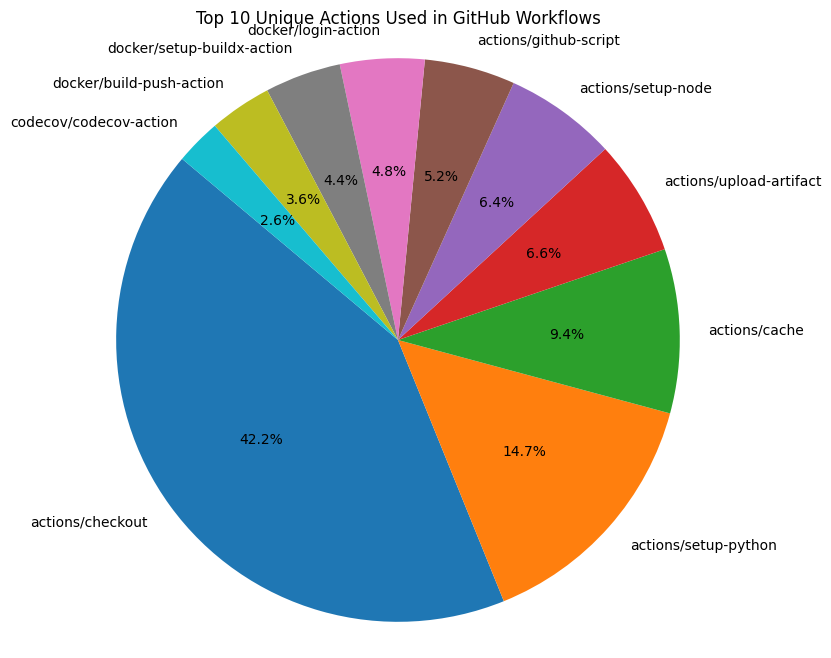

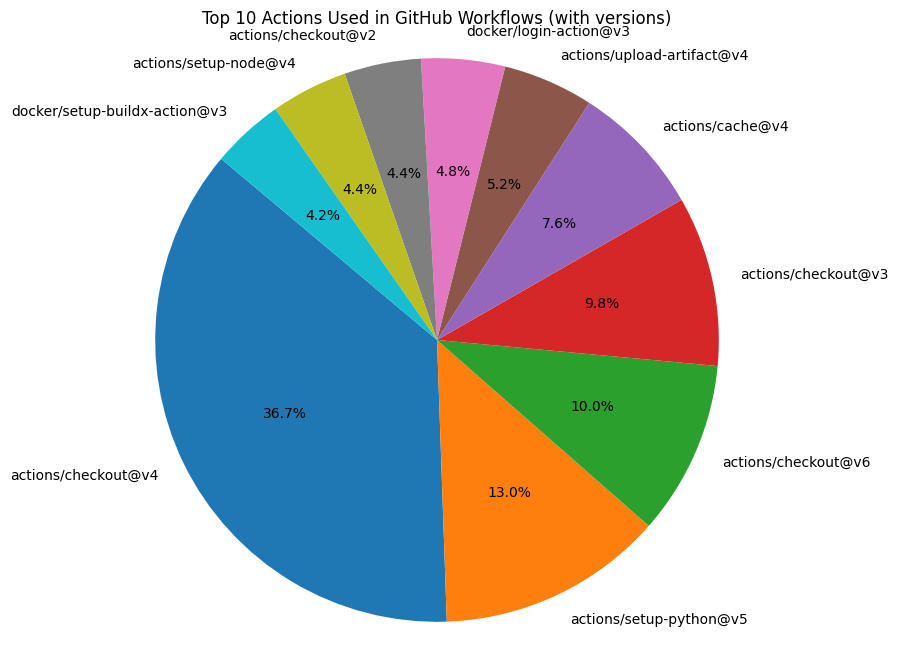

In [23]:
# grafico a torta per total_uses_counter_unique e total_uses_counter con almeno 10 utilizzi
import matplotlib.pyplot as plt

def plot_pie_chart(counter, title):
    labels, values = zip(*counter.most_common(10))
    plt.figure(figsize=(8, 8))
    plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140)
    plt.title(title)
    plt.axis('equal')
    plt.show()

plot_pie_chart(total_uses_counter_unique, "Top 10 Unique Actions Used in GitHub Workflows")
plot_pie_chart(total_uses_counter, "Top 10 Actions Used in GitHub Workflows (with versions)")

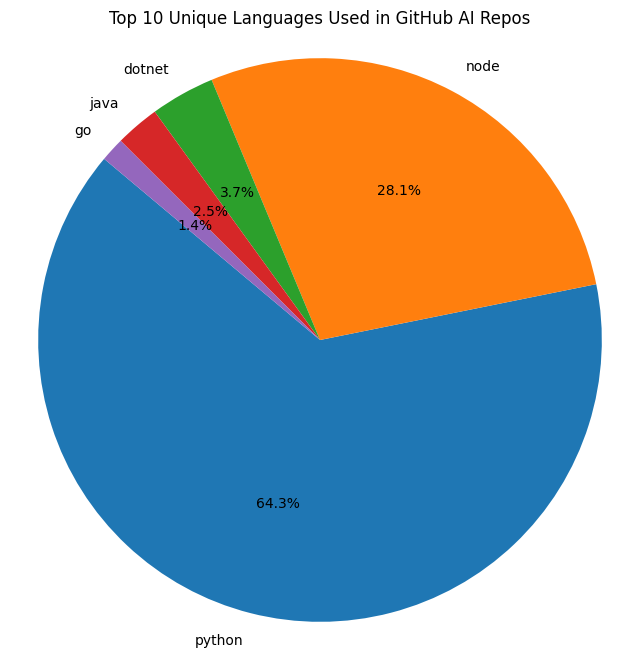

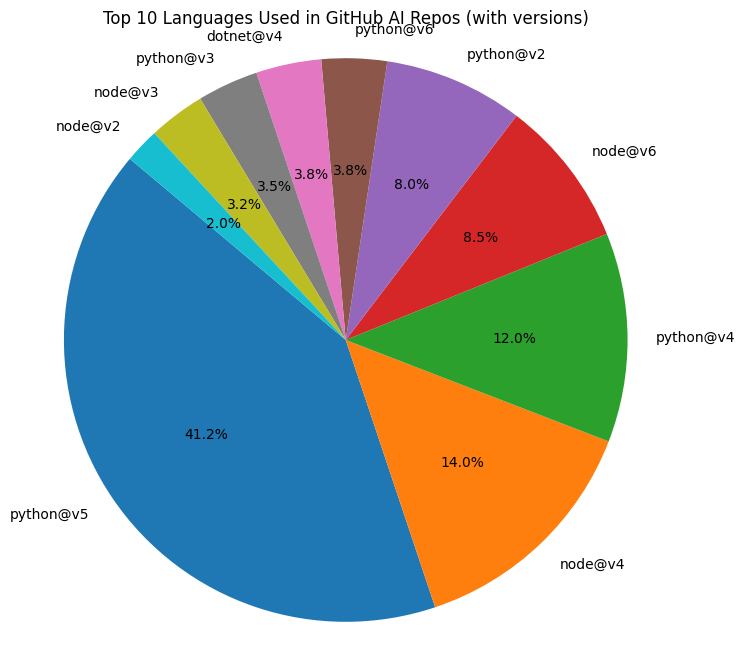

In [28]:
plot_pie_chart(most_used_languages, "Top 10 Unique Languages Used in GitHub AI Repos")
plot_pie_chart(most_used_languages_version, "Top 10 Languages Used in GitHub AI Repos (with versions)")